# 60-day evaluation of resource-allocation policies

This notebook is the primary report study for the optimization evaluation and staffing management question. It includes the full policy grid, the A_/O_ duration sensitivity, and the leave-two-out stress test. Every simulation explicitly uses the active lifecycle: active service sessions are sampled from `simulation_inputs_active.json`, while suspensions, resumptions, aborts, withdrawals, and non-active waiting remain separate lifecycle mechanisms.

The experiment uses the deployed BPMN/Petri-net process, repaired decision-point probabilities, visit-aware branching, contextual OrgModel permissions, calendar availability, and common random numbers (CRN). The fitted distribution sampler is fixed as the basic report baseline before comparing policies; the separate Section 1.3 validation records its fit relative to the ML alternatives. The newly retrained decision-rule artifact is intentionally not used because this study's branching mode remains `visit`. Results and report hand-off values are written under horizon-specific names.

**Execution order.** Run this primary report study only after the Section 1.3
notebooks and the 10- and 30-day evaluation notebooks. Its final cell rejects
missing or stale horizon configurations before exporting report values.

In [1]:
import hashlib
import importlib
import json
import sys
from pathlib import Path

ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "analysis").is_dir() and (path / "simulation").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if sys.prefix == sys.base_prefix:
    raise RuntimeError(
        'Select the registered BPIC17 (venv) kernel before running this notebook.'
    )
print(f'Notebook interpreter: {sys.executable}')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from analysis.availability import YearlyAvailability
from analysis.tum_style import (
    TUM_BLUE, TUM_GRAY, TUM_GRAY_DARK, TUM_ORANGE, TUM_RED, TUM_TEAL,
    apply_tum_style, save_figure,
)
from simulation.components import petri_process as petri_process_module
from simulation.components import process as process_module
from simulation.components import resource as resource_module
from scripts import opt_metrics as om
from scripts import run_experiments as R
from scripts.eval_lifecycle import validate_lifecycle_validation_artifact

# Notebook kernels can outlive source-code changes. Reload the project
# modules in dependency order so Run All always uses the current checkout.
resource_module = importlib.reload(resource_module)
process_module = importlib.reload(process_module)
petri_process_module = importlib.reload(petri_process_module)
om = importlib.reload(om)
R = importlib.reload(R)

apply_tum_style()
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DAY = 86_400.0
RESULT_DIR = ROOT / "output" / "evaluation_60"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_INPUT_DIR = ROOT / "output" / "report_inputs"
REPORT_INPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSING_VALIDATION_PATH = ROOT / "output/validation/lifecycle_active/distribution.json"
if not PROCESSING_VALIDATION_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {PROCESSING_VALIDATION_PATH}; run python scripts/run_lifecycle_validation.py"
    )
validate_lifecycle_validation_artifact(
    json.loads(PROCESSING_VALIDATION_PATH.read_text()), "distribution"
)

Notebook interpreter: /Users/danielsich/dev/Ent/bpic17-process-mining-group-assignment/venv/bin/python


## 1. Experimental design and provenance

Four paired replications balance precision and notebook runtime. The 60-day horizon gives long-running cases more time to reach completion and exposes every weekday roster pattern repeatedly. The study runs 12 policy replications, 12 paired atomic-duration sensitivity replications, and eight leave-two-out replications; the random-policy baseline is reused for staffing. Confidence intervals use Student's *t* distribution and should be read as simulation uncertainty, not uncertainty about the historical population.

The policies are R-RMA (`random`), Piled Execution (`piled`), and the middle k-Batching setting (`k=5`) as a representative batching policy. Repeating the entire k-sweep here would add no new evaluation concept and is disproportionately expensive under the active lifecycle; the dedicated k-Batching subsection covers parameter sensitivity. Cycle time is calculated only for naturally completed cases; completion counts and milestone reach rates are reported with it to expose horizon truncation and survivorship effects. Resource metrics include every human in the active OrgModel pool, including staff who perform no work in a run. The calendar-designated automated account remains part of the process but is excluded from staffing metrics.

Every active run uses unit resource capacity and a seeded draw from the fitted `p_work` roster. Policies sharing a replication seed therefore face the same realized workforce. Cache provenance fingerprints the Petri net and decision-point tables, metric and simulation code, policies, arrivals, permissions, availability, and lifecycle inputs; changing any of them invalidates the cached result.

In [2]:
SEEDS = [1, 2, 3, 4]
HORIZON_DAYS = 60
POLICIES = ["random", "piled", "kbatch5"]
CACHE_SCHEMA_VERSION = 4
PROVENANCE_SHA256 = R.evaluation_provenance_hashes()
POLICY_LABELS = {
    "random": "R-RMA",
    "piled": "R-PE",
    "kbatch5": "k=5",
}

RUN_CONFIG = {
    "horizon_days": HORIZON_DAYS,
    "seeds": SEEDS,
    "scenario": "normal",
    "crn": True,
    "process_model": "advanced",
    "branching_mode": "visit",
    "permissions": "orgmodel",
    "lifecycle_mode": "active",
    "processing_time_mode": "distribution",
    "atomic_duration_scale": 1.0,
    "capacity": R.capacity_for_mode("active"),
    "roster_seed": R.DEFAULT_ROSTER_SEED,
    "arrival_model": "mdn" if R.USE_MDN_ARRIVALS else "parametric",
}

calendar = YearlyAvailability.from_json(ROOT / "models" / "availability_model.json")
permissions, _ = R.load_permission_model(RUN_CONFIG["permissions"], seed=SEEDS[0])
resource_pool = set(permissions.resources())
human_resources = resource_pool - calendar.system
automated_resources = resource_pool & calendar.system

print(json.dumps(RUN_CONFIG, indent=2))
print(json.dumps({"provenance_sha256": PROVENANCE_SHA256}, indent=2))
print(
    f"Active pool: {len(resource_pool)} resources = {len(human_resources)} human "
    f"+ {len(automated_resources)} automated {sorted(automated_resources)}"
)

{
  "horizon_days": 60,
  "seeds": [
    1,
    2,
    3,
    4
  ],
  "scenario": "normal",
  "crn": true,
  "process_model": "advanced",
  "branching_mode": "visit",
  "permissions": "orgmodel",
  "lifecycle_mode": "active",
  "processing_time_mode": "distribution",
  "atomic_duration_scale": 1.0,
  "capacity": 1,
  "roster_seed": 42,
  "arrival_model": "mdn"
}
{
  "provenance_sha256": {
    "analysis/availability.py": "279cfe7671ae25009ecdf9efd604ac0f75715605489d4b2885e992190993f2f3",
    "analysis/permissions.py": "45f3720d45863f6e36de5dea408e21a25466ad984c6c9a86b1206cfad3f860d5",
    "models/case_attributes.json": "97b2c091c50c0bc7ad247215dd4bcfbf2de622be0a5b88b454a6d1c6cc140ddb",
    "models/permissions_orgmodel.json": "e9b97b45dcbfe451e52eedfac47bc363feaf606c02a883a49e2640634d065b24",
    "scripts/opt_metrics.py": "a5ca575c4b2a9548abf1a3cdd838c625d3327637a24d39a526e8ecb8ef972998",
    "scripts/run_experiments.py": "5fd6da7bae5c9e12abe6521f4803da0998c6d6cfc922e5a5289f49d025fc96e7

In [3]:
def ci95(values):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) < 2:
        return np.nan
    return float(stats.t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values)))


def expected_roster_seed(seed):
    base = RUN_CONFIG["roster_seed"]
    return None if base is None else base + seed


def assert_cached_diagnostics(cached, seed):
    row = cached["row"]
    assert row["effective_capacity"] == RUN_CONFIG["capacity"]
    assert row["effective_roster_seed"] == expected_roster_seed(seed)
    assert row["arrival_model"] == RUN_CONFIG["arrival_model"]
    assert row["atomic_duration_scale"] >= 0.0
    assert row["unpermitted_activities"] == 0
    assert row["missing_resource_starts"] == 0
    assert row["still_queued_at_end"] >= 0
    assert row["max_session_guard_reached"] == 0
    assert row["max_session_guard_forced_completions"] == 0
    if row["effective_capacity"] == 1:
        assert row["max_resource_occupation"] <= 1.0 + 1e-9


def run_and_measure(
    policy, seed, *, excluded=None, resource_subset=None, cache_key="policy",
    atomic_duration_scale=None,
):
    subset = human_resources if resource_subset is None else set(resource_subset)
    excluded_set = set(excluded or ())
    effective_atomic_scale = (
        RUN_CONFIG["atomic_duration_scale"]
        if atomic_duration_scale is None else float(atomic_duration_scale)
    )
    effective_roster_seed = expected_roster_seed(seed)
    cache_dir = RESULT_DIR / "run_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{cache_key}_{policy}_seed{seed}.json"
    cache_configuration = {
        **RUN_CONFIG,
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "provenance_sha256": PROVENANCE_SHA256,
        "effective_capacity": RUN_CONFIG["capacity"],
        "effective_roster_seed": effective_roster_seed,
        "policy": policy,
        "seed": seed,
        "excluded_resources": sorted(excluded_set),
        "resource_subset": sorted(subset),
        "atomic_duration_scale": effective_atomic_scale,
    }
    if cache_path.exists():
        cached = json.loads(cache_path.read_text())
        if cached.get("cache_configuration") == cache_configuration:
            assert_cached_diagnostics(cached, seed)
            print(f"cached   policy={policy:>8} seed={seed} completed={cached['row']['completed_cases']:4d}")
            return cached

    df, meta = R.run_once(
        policy,
        seed,
        HORIZON_DAYS,
        RUN_CONFIG["scenario"],
        RUN_CONFIG["crn"],
        RUN_CONFIG["process_model"],
        RUN_CONFIG["branching_mode"],
        lifecycle_mode=RUN_CONFIG["lifecycle_mode"],
        processing_time_mode=RUN_CONFIG["processing_time_mode"],
        permissions=RUN_CONFIG["permissions"],
        excluded_override=excluded,
        roster_seed=RUN_CONFIG["roster_seed"],
        capacity=RUN_CONFIG["capacity"],
        atomic_duration_scale=effective_atomic_scale,
    )
    expected = {
        "horizon_days": HORIZON_DAYS,
        "scenario": RUN_CONFIG["scenario"],
        "crn": RUN_CONFIG["crn"],
        "process_model": RUN_CONFIG["process_model"],
        "branching_mode": RUN_CONFIG["branching_mode"],
        "permissions": RUN_CONFIG["permissions"],
        "lifecycle_mode": RUN_CONFIG["lifecycle_mode"],
        "processing_time_mode": RUN_CONFIG["processing_time_mode"],
        "atomic_duration_scale": effective_atomic_scale,
        "capacity": RUN_CONFIG["capacity"],
        "roster_seed": effective_roster_seed,
        "arrival_model": RUN_CONFIG["arrival_model"],
    }
    for key, value in expected.items():
        assert meta["configuration"][key] == value, (key, meta["configuration"])
    assert "work_item_id" in df.columns and df["work_item_id"].notna().any()

    metrics = om.evaluate(
        df,
        arrival_times=meta["arrival_times"],
        availability_seconds=meta["availability_seconds"],
        availability_intervals=meta["availability_intervals"],
        completed_case_ids=meta["completed_case_ids"],
        resource_subset=subset,
    )
    work_occupation = om.average_resource_occupation(
        df,
        availability_seconds=meta["availability_seconds"],
        availability_intervals=meta["availability_intervals"],
        resource_subset=subset,
        activity_prefixes=("W_",),
    )
    work_fairness = om.resource_fairness(work_occupation["per_resource"])
    work_switching = om.resource_activity_switch_rate(
        df, activity_prefixes=("W_",)
    )
    work_balance = om.rolling_workload_balance(
        df, resource_subset=subset, activity_prefixes=("W_",)
    )
    lifecycle = meta["lifecycle_diagnostics"]
    exposure = meta["activity_type_exposure"]
    diagnostics = R.validate_resource_diagnostics(
        df,
        meta["resource_stats"],
        metrics["occupation"]["per_resource"],
        meta["configuration"]["capacity"],
    )
    custom = metrics["custom_metrics"]
    arrivals = len(meta["arrival_times"])
    completed = metrics["case_filter"]["n_cases_completed"]
    first_offer = custom["time_to_first_offer"]
    decision = custom["time_to_decision"]
    row = {
        "policy": policy,
        "seed": seed,
        "excluded_resources": ",".join(meta["configuration"]["excluded_resources"]),
        "effective_capacity": meta["configuration"]["capacity"],
        "effective_roster_seed": meta["configuration"]["roster_seed"],
        "arrival_model": meta["configuration"]["arrival_model"],
        "atomic_duration_scale": meta["configuration"]["atomic_duration_scale"],
        **diagnostics,
        "arrivals": arrivals,
        "completed_cases": completed,
        "completion_share": completed / arrivals if arrivals else np.nan,
        "cycle_time_days": metrics["cycle_time"]["avg_cycle_time_s"] / DAY,
        "p95_cycle_days": metrics["cycle_time"]["p95_cycle_time_s"] / DAY,
        "occupation": metrics["occupation"]["avg_resource_occupation"],
        "fairness": metrics["fairness"]["resource_fairness"],
        "w_occupation": work_occupation["avg_resource_occupation"],
        "w_fairness": work_fairness["resource_fairness"],
        "time_to_first_offer_days": first_offer["mean_s"] / DAY,
        "first_offer_reach_share": first_offer["n_cases_reaching_it"] / arrivals if arrivals else np.nan,
        "time_to_decision_days": decision["mean_s"] / DAY,
        "decision_reach_share": decision["n_cases_reaching_it"] / arrivals if arrivals else np.nan,
        "case_handover_rate": custom["handover_rate"]["handover_rate"],
        "activity_switch_rate": custom["resource_activity_switch_rate"]["activity_switch_rate"],
        "rolling_workload_std": custom["rolling_workload_balance"]["mean_window_std"],
        "w_activity_switch_rate": work_switching["activity_switch_rate"],
        "w_rolling_workload_std": work_balance["mean_window_std"],
        "w_event_share": exposure["w_event_share"],
        "ao_event_share": exposure["ao_event_share"],
        "w_busy_share": exposure["w_busy_share"],
        "ao_busy_share": exposure["ao_busy_share"],
        "median_sessions_per_work_item": lifecycle["median_sessions_per_work_item"],
        "max_sessions_per_work_item": lifecycle["max_sessions_per_work_item"],
        "max_session_guard_reached": lifecycle["max_session_guard_reached"],
        "max_session_guard_forced_completions": lifecycle["max_session_guard_forced_completions"],
        "withdrawals": lifecycle["withdrawals"],
        "rare_shortened_work_items": lifecycle["rare_work_items_routed"].get("W_Shortened completion ", 0),
        "rare_personal_loan_work_items": lifecycle["rare_work_items_routed"].get("W_Personal Loan collection", 0),
        "resources_evaluated": metrics["occupation"]["n_resources_evaluated"],
        "zero_availability_resources": metrics["occupation"]["n_resources_zero_availability"],
        "busy_outside_availability_hours": (
            metrics["occupation"]["busy_seconds_outside_availability"] / 3600.0
        ),
    }
    instances = om.paired_instances(df)
    human_counts = instances.loc[
        instances["resource"].isin(human_resources), "resource"
    ].value_counts()
    work_human_counts = instances.loc[
        instances["resource"].isin(human_resources)
        & instances["activity"].fillna("").str.startswith("W_"),
        "resource",
    ].value_counts()
    result = {
        "cache_configuration": cache_configuration,
        "row": row,
        "resource_stats": meta["resource_stats"],
        "resource_occupation": metrics["occupation"]["per_resource"],
        "w_resource_occupation": work_occupation["per_resource"],
        "lifecycle_diagnostics": lifecycle,
        "activity_type_exposure": exposure,
        "human_throughput_share": (
            (human_counts / human_counts.sum()).to_dict() if human_counts.sum() else {}
        ),
        "w_human_throughput_share": (
            (work_human_counts / work_human_counts.sum()).to_dict()
            if work_human_counts.sum() else {}
        ),
    }
    assert_cached_diagnostics(result, seed)
    cache_path.write_text(json.dumps(result, indent=2, sort_keys=True) + "\n")
    print(f"finished policy={policy:>8} seed={seed} completed={completed:4d}")
    return result


def summarize(rows, group="policy"):
    frame = pd.DataFrame(rows)
    metrics = [
        "cycle_time_days", "p95_cycle_days", "occupation", "fairness",
        "w_occupation", "w_fairness",
        "completed_cases", "completion_share", "time_to_first_offer_days",
        "first_offer_reach_share", "time_to_decision_days", "decision_reach_share",
        "case_handover_rate", "activity_switch_rate", "rolling_workload_std",
        "w_activity_switch_rate", "w_rolling_workload_std",
        "w_event_share", "ao_event_share", "w_busy_share", "ao_busy_share",
        "median_sessions_per_work_item", "max_sessions_per_work_item",
        "max_session_guard_reached", "max_session_guard_forced_completions",
        "withdrawals", "rare_shortened_work_items",
        "rare_personal_loan_work_items",
    ]
    records = []
    for name, part in frame.groupby(group, sort=False):
        record = {group: name, "n_replications": len(part)}
        for metric in metrics:
            record[metric] = part[metric].mean()
            record[f"{metric}_ci95"] = ci95(part[metric])
        records.append(record)
    return pd.DataFrame(records).set_index(group), frame

## 2. Policy comparison

The following cell performs 12 active-lifecycle simulations over a 60-day horizon. Each run is checkpointed as JSON immediately after completion. A checkpoint is reused only when the full configuration, cache schema, effective capacity and roster seed, and every code-and-input fingerprint match. Cached and fresh runs pass the same resource guardrails. The checkpoints are local derived artifacts; only aggregate result tables are versioned.

In [4]:
policy_runs = {
    policy: [run_and_measure(policy, seed) for seed in SEEDS]
    for policy in POLICIES
}
policy_summary, policy_run_metrics = summarize(
    [run["row"] for runs in policy_runs.values() for run in runs]
)

policy_run_metrics.to_csv(RESULT_DIR / "policy_run_metrics.csv", index=False)
policy_summary.to_csv(RESULT_DIR / "policy_summary.csv")
(RESULT_DIR / "configuration.json").write_text(json.dumps({
    **RUN_CONFIG,
    "cache_schema_version": CACHE_SCHEMA_VERSION,
    "provenance_sha256": PROVENANCE_SHA256,
    "effective_roster_seed_by_seed": {
        str(seed): expected_roster_seed(seed) for seed in SEEDS
    },
    "policies": POLICIES,
    "resource_pool_size": len(resource_pool),
    "human_resource_count": len(human_resources),
    "automated_resources": sorted(automated_resources),
}, indent=2) + "\n")

display_columns = [
    "cycle_time_days", "completed_cases", "completion_share", "occupation",
    "fairness", "w_occupation", "w_fairness", "activity_switch_rate",
    "w_activity_switch_rate", "time_to_decision_days", "decision_reach_share",
]
policy_summary[display_columns].rename(index=POLICY_LABELS).round(3)

[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 265258, Cases started: 4371, Cases completed: 3074, Wall time: 38.756s
finished policy=  random seed=1 completed=3074
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 262495, Cases started: 4296, Cases completed: 2957, Wall time: 39.068s
finished policy=  random seed=2 completed=2957
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 275863, Cases started: 4526, Cases completed: 3177, Wall time: 42.025s
finished policy=  random seed=3 completed=3177
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 263900, Cases started: 4297, Cases completed: 3003, Wall time: 40.114s
finished policy=  random seed=4 completed=3003
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 263838, Cases started: 4371, Cases complete

,cycle_time_days,completed_cases,completion_share,occupation,fairness,w_occupation,w_fairness,activity_switch_rate,w_activity_switch_rate,time_to_decision_days,decision_reach_share
policy,,,,,,,,,,,
R-RMA,1.498,"3,052.750",0.698,0.372,0.270,0.041,0.037,0.725,0.122,0.687,0.507
R-PE,1.590,"3,032.250",0.693,0.370,0.271,0.041,0.037,0.627,0.118,0.775,0.503
k=5,6.741,"2,563.500",0.587,0.329,0.242,0.030,0.033,0.669,0.087,5.449,0.455


In [5]:
def paired_deltas(frame, baseline="random"):
    columns = ["cycle_time_days", "completed_cases", "activity_switch_rate", "time_to_decision_days"]
    records = []
    base = frame[frame["policy"] == baseline].set_index("seed")
    for policy in POLICIES:
        if policy == baseline:
            continue
        other = frame[frame["policy"] == policy].set_index("seed")
        common = base.index.intersection(other.index)
        record = {"policy_vs_random": policy, "n_pairs": len(common)}
        for column in columns:
            delta = other.loc[common, column] - base.loc[common, column]
            record[f"delta_{column}"] = delta.mean()
            record[f"delta_{column}_ci95"] = ci95(delta)
        records.append(record)
    return pd.DataFrame(records).set_index("policy_vs_random")


policy_deltas = paired_deltas(policy_run_metrics)
policy_deltas.to_csv(RESULT_DIR / "policy_paired_deltas.csv")
policy_deltas.round(3)

,n_pairs,delta_cycle_time_days,delta_cycle_time_days_ci95,delta_completed_cases,delta_completed_cases_ci95,delta_activity_switch_rate,delta_activity_switch_rate_ci95,delta_time_to_decision_days,delta_time_to_decision_days_ci95
policy_vs_random,,,,,,,,,
piled,4,0.091,0.029,-20.500,26.957,-0.098,0.010,0.088,0.011
kbatch5,4,5.243,2.012,-489.250,224.749,-0.056,0.012,4.762,2.349


The compact trade-off plot is retained because it combines the two outcome measures needed to detect survivorship: lower cycle time is only desirable when it is not obtained by completing fewer cases. The remaining measures are more legible in the tables than as separate charts.

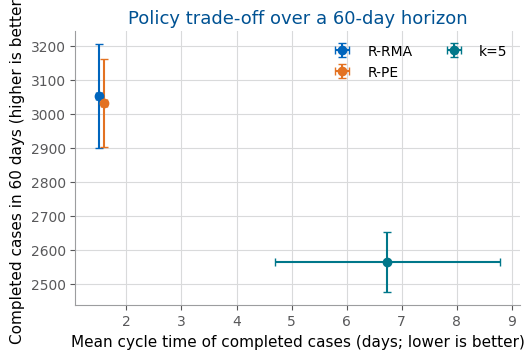

In [6]:
fig, ax = plt.subplots(figsize=(5.4, 3.7))
colors = [TUM_BLUE, TUM_ORANGE, TUM_TEAL]
for color, policy in zip(colors, POLICIES):
    row = policy_summary.loc[policy]
    ax.errorbar(
        row["cycle_time_days"], row["completed_cases"],
        xerr=row["cycle_time_days_ci95"], yerr=row["completed_cases_ci95"],
        fmt="o", ms=6, capsize=3, color=color, label=POLICY_LABELS[policy],
    )
ax.set_xlabel("Mean cycle time of completed cases (days; lower is better)", fontsize=11)
ax.set_ylabel(f"Completed cases in {HORIZON_DAYS} days (higher is better)", fontsize=11)
ax.set_title(f"Policy trade-off over a {HORIZON_DAYS}-day horizon", fontsize=13)
ax.tick_params(labelsize=10)
ax.legend(ncol=2, fontsize=10)
fig.tight_layout()
save_figure(fig, "04_60_policy_tradeoff")
plt.show()

### Operational diagnostics

The case-handover rate describes continuity within one customer case. It is not a direct test of Piled Execution. Piled Execution instead tries to keep a resource on the same activity, so `activity_switch_rate` is the relevant mechanism measure. The W_-only measures isolate fitted work sessions from A_/O_ state changes whose durations are assumed. Event-row and busy-time shares show how strongly each view influences a run. Milestone means are accompanied by the share of arrivals that reach each milestone; comparing means alone would condition on a policy-dependent subset of cases.

In [7]:
diagnostic_columns = [
    "time_to_first_offer_days", "first_offer_reach_share",
    "time_to_decision_days", "decision_reach_share",
    "case_handover_rate", "activity_switch_rate", "rolling_workload_std",
    "w_activity_switch_rate", "w_rolling_workload_std",
    "w_event_share", "ao_event_share", "w_busy_share", "ao_busy_share",
    "median_sessions_per_work_item", "max_sessions_per_work_item",
    "max_session_guard_reached", "max_session_guard_forced_completions",
    "withdrawals", "rare_shortened_work_items",
    "rare_personal_loan_work_items",
]
policy_summary[diagnostic_columns].rename(index=POLICY_LABELS).round(3)

,time_to_first_offer_days,first_offer_reach_share,time_to_decision_days,decision_reach_share,case_handover_rate,activity_switch_rate,rolling_workload_std,w_activity_switch_rate,w_rolling_workload_std,w_event_share,ao_event_share,w_busy_share,ao_busy_share,median_sessions_per_work_item,max_sessions_per_work_item,max_session_guard_reached,max_session_guard_forced_completions,withdrawals,rare_shortened_work_items,rare_personal_loan_work_items
policy,,,,,,,,,,,,,,,,,,,,
R-RMA,0.163,0.975,0.687,0.507,0.815,0.725,0.107,0.122,0.024,0.192,0.808,0.118,0.882,1.000,11.000,0.000,0.000,130.000,0.000,0.000
R-PE,0.163,0.975,0.775,0.503,0.820,0.627,0.107,0.118,0.025,0.191,0.809,0.119,0.881,1.000,11.000,0.000,0.000,127.500,0.000,0.000
k=5,2.222,0.906,5.449,0.455,0.899,0.669,0.093,0.087,0.020,0.170,0.830,0.103,0.897,1.000,10.750,0.000,0.000,"1,133.250",0.000,0.000


### Atomic A_/O_ duration sensitivity

BPIC-17 does not provide start/complete pairs for A_ and O_ state changes, so their service durations are assumptions rather than fitted observations. The main specification retains the current durations (`atomic_duration_scale=1`). The paired lower-bound specification sets those durations to zero while retaining permission checks, calendars, resource assignment, and event order. W_ session durations remain unchanged. A policy conclusion that changes between these specifications should be reported as model-dependent.

In [8]:
atomic_zero_runs = {
    policy: [
        run_and_measure(
            policy, seed, cache_key="atomic_zero", atomic_duration_scale=0.0
        )
        for seed in SEEDS
    ]
    for policy in POLICIES
}
atomic_zero_metrics = pd.DataFrame([
    run["row"] for runs in atomic_zero_runs.values() for run in runs
])
atomic_sensitivity_runs = pd.concat([
    policy_run_metrics, atomic_zero_metrics
], ignore_index=True)
atomic_sensitivity_runs.to_csv(
    RESULT_DIR / "atomic_duration_sensitivity_runs.csv", index=False
)

atomic_sensitivity_records = []
for policy in POLICIES:
    base = policy_run_metrics[policy_run_metrics["policy"] == policy].set_index("seed")
    zero = atomic_zero_metrics[atomic_zero_metrics["policy"] == policy].set_index("seed")
    common = base.index.intersection(zero.index)
    record = {"policy": policy, "n_pairs": len(common)}
    for metric in [
        "cycle_time_days", "completed_cases", "completion_share",
        "occupation", "fairness", "w_occupation", "w_fairness",
        "activity_switch_rate", "w_activity_switch_rate",
    ]:
        delta = zero.loc[common, metric] - base.loc[common, metric]
        record[f"delta_{metric}"] = delta.mean()
        record[f"delta_{metric}_ci95"] = ci95(delta)
    atomic_sensitivity_records.append(record)
atomic_sensitivity = pd.DataFrame(atomic_sensitivity_records).set_index("policy")
atomic_sensitivity.to_csv(RESULT_DIR / "atomic_duration_sensitivity.csv")
assert atomic_zero_metrics["atomic_duration_scale"].eq(0.0).all()
assert atomic_zero_metrics["max_session_guard_reached"].eq(0).all()
atomic_sensitivity.rename(index=POLICY_LABELS).round(3)

[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 265643, Cases started: 4371, Cases completed: 3102, Wall time: 37.604s
finished policy=  random seed=1 completed=3102
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 264554, Cases started: 4296, Cases completed: 3036, Wall time: 42.047s
finished policy=  random seed=2 completed=3036
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 277578, Cases started: 4526, Cases completed: 3235, Wall time: 39.540s
finished policy=  random seed=3 completed=3235
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 265634, Cases started: 4297, Cases completed: 3069, Wall time: 38.501s
finished policy=  random seed=4 completed=3069
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 265645, Cases started: 4371, Cases complete

,n_pairs,delta_cycle_time_days,delta_cycle_time_days_ci95,delta_completed_cases,delta_completed_cases_ci95,delta_completion_share,delta_completion_share_ci95,delta_occupation,delta_occupation_ci95,delta_fairness,delta_fairness_ci95,delta_w_occupation,delta_w_occupation_ci95,delta_w_fairness,delta_w_fairness_ci95,delta_activity_switch_rate,delta_activity_switch_rate_ci95,delta_w_activity_switch_rate,delta_w_activity_switch_rate_ci95
policy,,,,,,,,,,,,,,,,,,,
R-RMA,4,-0.677,0.114,57.750,34.433,0.013,0.008,-0.330,0.015,-0.232,0.010,0.001,0.001,0.001,0.003,-0.004,0.006,0.023,0.005
R-PE,4,-0.769,0.100,79.500,19.161,0.018,0.004,-0.328,0.018,-0.234,0.011,0.001,0.003,0.000,0.002,0.052,0.017,0.025,0.008
k=5,4,-5.792,2.019,583.000,214.514,0.133,0.044,-0.286,0.015,-0.191,0.012,0.012,0.002,0.019,0.003,-0.021,0.002,0.008,0.013


## 3. Staffing question: which two employees can be removed with the least operational harm?

The previous report treated a 17-resource legacy map as the deployed workforce and claimed that `User_5` was an exclusive permission holder. The current OrgModel contains 144 resources. We therefore recompute the candidate pool and permission redundancy from the model actually used by the simulator.

Criticality is a screening score, not a causal estimate. Two scores combine occupation, throughput share, and permission breadth: one uses all activities and one uses fitted W_ work only. The conservative score takes their maximum, so an employee is low-criticality only under both duration views. A human who is the sole candidate for a recognized `(activity, case type, weekday)` context is excluded from removal rather than folded into the weighted score. The leave-two-out simulations then test the two lowest-scoring eligible employees against a deliberately high-criticality contrast under the same paired seeds.

In [9]:
# Contextual permission redundancy in the deployed OrgModel.
model_case_types = sorted({
    case_type
    for entries in permissions._index.values()
    for _, case_type, _ in entries
    if case_type
}) or [None]
model_weekdays = pd.date_range("2016-01-04", periods=7, freq="D")
sole_candidate_contexts = pd.Series(0, index=sorted(human_resources), dtype=int)
recognized_contexts = 0
for activity in permissions._index:
    for case_type in model_case_types:
        for when in model_weekdays:
            candidates = set(permissions.candidates(activity, case_type=case_type, when=when)) & human_resources
            if candidates:
                recognized_contexts += 1
            if len(candidates) == 1:
                sole_candidate_contexts.loc[next(iter(candidates))] += 1

base_runs = policy_runs["random"]
occupation_by_resource = pd.DataFrame([
    run["resource_occupation"] for run in base_runs
]).reindex(columns=sorted(human_resources), fill_value=0.0).mean()

throughput_frames = [
    pd.Series(run["human_throughput_share"], dtype=float) for run in base_runs
]
throughput_share = pd.concat(throughput_frames, axis=1).reindex(sorted(human_resources)).fillna(0.0).mean(axis=1)
work_occupation_by_resource = pd.DataFrame([
    run["w_resource_occupation"] for run in base_runs
]).reindex(columns=sorted(human_resources), fill_value=0.0).mean()
work_throughput_frames = [
    pd.Series(run["w_human_throughput_share"], dtype=float) for run in base_runs
]
work_throughput_share = pd.concat(work_throughput_frames, axis=1).reindex(
    sorted(human_resources)
).fillna(0.0).mean(axis=1)

permission_breadth = pd.Series({
    resource: sum(
        any(resource in members for members, _, _ in entries)
        for entries in permissions._index.values()
    )
    for resource in human_resources
})

def normalize(series):
    span = series.max() - series.min()
    return (series - series.min()) / span if span else pd.Series(0.0, index=series.index)

criticality = pd.DataFrame({
    "occupation": occupation_by_resource,
    "throughput_share": throughput_share,
    "w_occupation": work_occupation_by_resource,
    "w_throughput_share": work_throughput_share,
    "permission_breadth": permission_breadth,
    "sole_candidate_contexts": sole_candidate_contexts,
}).reindex(sorted(human_resources)).fillna(0.0)
criticality["all_activity_score"] = (
    0.4 * normalize(criticality["occupation"])
    + 0.4 * normalize(criticality["throughput_share"])
    + 0.2 * normalize(criticality["permission_breadth"])
)
criticality["fitted_work_score"] = (
    0.4 * normalize(criticality["w_occupation"])
    + 0.4 * normalize(criticality["w_throughput_share"])
    + 0.2 * normalize(criticality["permission_breadth"])
)
# Conservative ranking: a resource is low-criticality only if neither
# the current all-activity model nor the fitted-work view ranks it highly.
criticality["criticality_score"] = criticality[[
    "all_activity_score", "fitted_work_score"
]].max(axis=1)
criticality = criticality.sort_values("criticality_score")
protected_resources = set(criticality.index[criticality["sole_candidate_contexts"] > 0])
removal_candidates = criticality.drop(index=protected_resources)
if protected_resources:
    print("Protected from removal due to sole-candidate contexts:", sorted(protected_resources))
criticality.to_csv(RESULT_DIR / "resource_criticality.csv")

print(f"Recognized OrgModel contexts checked: {recognized_contexts}")
print(f"Single-human-candidate contexts: {int(sole_candidate_contexts.sum())}")
display(pd.concat([criticality.head(6), criticality.tail(6)]).round(4))

Recognized OrgModel contexts checked: 1735
Single-human-candidate contexts: 0


,occupation,throughput_share,w_occupation,w_throughput_share,permission_breadth,sole_candidate_contexts,all_activity_score,fitted_work_score,criticality_score
User_110,0.000,0.000,0.000,0.000,10,0,0.017,0.017,0.017
User_89,0.003,0.000,0.000,0.000,10,0,0.018,0.017,0.018
User_142,0.004,0.000,0.000,0.000,10,0,0.018,0.017,0.018
User_140,0.007,0.000,0.000,0.000,10,0,0.020,0.017,0.020
User_135,0.003,0.000,0.003,0.000,10,0,0.018,0.021,0.021
User_141,0.008,0.000,0.000,0.000,10,0,0.021,0.017,0.021
User_29,0.442,0.026,0.195,0.058,21,0,0.615,0.694,0.694
User_99,0.447,0.021,0.238,0.047,21,0,0.570,0.710,0.710
User_30,0.494,0.024,0.243,0.055,21,0,0.622,0.750,0.750
User_87,0.490,0.025,0.234,0.058,21,0,0.628,0.751,0.751


In [ ]:
remove_low = list(removal_candidates.index[:2])
remove_high = list(removal_candidates.index[-2:])
print("Low-criticality pair:", remove_low)
print("High-criticality contrast:", remove_high)

staffing_runs = {
    "baseline": base_runs,
    "remove_low": [
        run_and_measure(
            "random", seed, excluded=set(remove_low),
            resource_subset=human_resources - set(remove_low), cache_key="remove_low",
        )
        for seed in SEEDS
    ],
    "remove_high": [
        run_and_measure(
            "random", seed, excluded=set(remove_high),
            resource_subset=human_resources - set(remove_high), cache_key="remove_high",
        )
        for seed in SEEDS
    ],
}

staffing_summary, staffing_run_metrics = summarize([
    {**run["row"], "staffing_scenario": scenario}
    for scenario, runs in staffing_runs.items()
    for run in runs
], group="staffing_scenario")
staffing_run_metrics.to_csv(RESULT_DIR / "staffing_run_metrics.csv", index=False)
staffing_summary.to_csv(RESULT_DIR / "staffing_summary.csv")
display(staffing_summary[[
    "cycle_time_days", "completed_cases", "completion_share", "occupation",
    "fairness", "w_occupation", "w_fairness",
    "time_to_decision_days", "decision_reach_share",
]].round(3))

staffing_delta_records = []
staffing_base = staffing_run_metrics[
    staffing_run_metrics["staffing_scenario"] == "baseline"
].set_index("seed")
for scenario in ["remove_low", "remove_high"]:
    other = staffing_run_metrics[
        staffing_run_metrics["staffing_scenario"] == scenario
    ].set_index("seed")
    common = staffing_base.index.intersection(other.index)
    record = {"staffing_scenario_vs_baseline": scenario, "n_pairs": len(common)}
    for metric in [
        "cycle_time_days", "completed_cases", "occupation", "fairness",
        "w_occupation", "w_fairness",
        "time_to_decision_days", "decision_reach_share",
    ]:
        delta = other.loc[common, metric] - staffing_base.loc[common, metric]
        record[f"delta_{metric}"] = delta.mean()
        record[f"delta_{metric}_ci95"] = ci95(delta)
    staffing_delta_records.append(record)
staffing_paired_deltas = pd.DataFrame(staffing_delta_records).set_index(
    "staffing_scenario_vs_baseline"
)
staffing_paired_deltas.to_csv(RESULT_DIR / "staffing_paired_deltas.csv")
staffing_paired_deltas.round(3)

Low-criticality pair: ['User_110', 'User_89']
High-criticality contrast: ['User_68', 'User_75']
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 265244, Cases started: 4371, Cases completed: 3077, Wall time: 44.661s
finished policy=  random seed=1 completed=3077
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 262495, Cases started: 4296, Cases completed: 2957, Wall time: 42.299s
finished policy=  random seed=2 completed=2957
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 275863, Cases started: 4526, Cases completed: 3177, Wall time: 49.186s
finished policy=  random seed=3 completed=3177
[Engine] Starting simulation (duration=5184000s)
[Engine] Simulation complete. Events processed: 263900, Cases started: 4297, Cases completed: 3003, Wall time: 43.677s
finished policy=  random seed=4 completed=3003
[Engine] Starting simulation (duration=51840

In [ ]:
baseline = staffing_summary.loc["baseline"]
impact = pd.DataFrame({
    scenario: {
        "Cycle time": 100 * (staffing_summary.loc[scenario, "cycle_time_days"] / baseline["cycle_time_days"] - 1),
        "Completed cases": 100 * (staffing_summary.loc[scenario, "completed_cases"] / baseline["completed_cases"] - 1),
        "Time to decision": 100 * (staffing_summary.loc[scenario, "time_to_decision_days"] / baseline["time_to_decision_days"] - 1),
    }
    for scenario in ["remove_low", "remove_high"]
}).T
impact.to_csv(RESULT_DIR / "staffing_relative_impact.csv")
impact.round(2)

The staffing chart is retained because the signs of the changes matter: a lower cycle-time mean can coexist with fewer completions and therefore indicate survivorship rather than improvement. The table remains the source for exact values.

In [ ]:
fig, ax = plt.subplots(figsize=(5.4, 3.6))
x = np.arange(len(impact.columns))
width = 0.34
for offset, (scenario, color, label) in enumerate([
    ("remove_low", TUM_BLUE, "Remove low-criticality pair"),
    ("remove_high", TUM_RED, "Remove high-criticality pair"),
]):
    values = impact.loc[scenario].to_numpy()
    bars = ax.bar(x + (offset - 0.5) * width, values, width, color=color, label=label)
    ax.bar_label(bars, fmt="%+.1f%%", fontsize=8, padding=2)
ax.axhline(0, color=TUM_GRAY_DARK, lw=0.9)
ax.set(
    xticks=x,
    xticklabels=impact.columns,
    ylabel="Change from baseline (%)",
    title=f"Operational impact over a {HORIZON_DAYS}-day horizon",
)
ax.set_ylabel("Change from baseline (%)", fontsize=11)
ax.set_title(f"Operational impact over a {HORIZON_DAYS}-day horizon", fontsize=13)
ax.tick_params(labelsize=10)
ax.legend(fontsize=10)
fig.tight_layout()
save_figure(fig, "04_60_staffing_impact")
plt.show()

## 4. Reproducibility checks and interpretation guardrails

- The runner requires `lifecycle_mode` as a keyword, so future notebooks cannot silently fall back to legacy elapsed durations.
- Every run records and checks its effective capacity, realized roster seed, and arrival model. Policies with the same replication seed use the same roster draw.
- Cache keys also fingerprint the Petri net, repaired decision-point probabilities, visit-conditioned branching, arrivals, permissions, policies, and fitted inputs.
- Active `start` and `resume` events must have an assigned resource, and the resource component must report no unpermitted activity. The number of work items still queued at the finite horizon is retained as a diagnostic rather than treated as completed work.
- Active mode uses unit resource capacity. Consequently, no human resource may have occupation above one.
- Session churn, withdrawals, and the two sparsely observed W_ routes are recorded for every run. Any activation of the 60-session completion guard fails the notebook instead of silently entering the results.
- CRN pairs the stochastic inputs by seed, making within-seed policy and staffing differences more informative than independent runs.
- Occupation is active busy time overlapping realized calendar availability, divided by that availability. Work continuing past shift end is retained separately as overtime rather than divided by scheduled hours. Staff with zero availability in the horizon are reported and excluded from the denominator; staff who are available but idle count as zero occupation.
- All-activity occupation includes assumed A_/O_ service durations. W_-only occupation uses the same availability denominator but only fitted work sessions. The zero-duration A_/O_ specification is a lower-bound sensitivity check, not a claim that state changes require no organizational handling.
- Cycle time conditions on natural completion. Completion counts, completion shares, and milestone reach shares must therefore accompany it.
- The criticality ranking is only a screening device. Resources that are the sole candidate for any recognized context are protected from removal. The leave-two-out experiment estimates finite-horizon operational effects; it does not include legal, ethical, financial, or employee-welfare considerations and should not be read as a real dismissal recommendation.

In [ ]:
all_run_metrics = pd.concat(
    [policy_run_metrics, staffing_run_metrics], ignore_index=True, sort=False
)

assert (
    policy_run_metrics["resources_evaluated"]
    + policy_run_metrics["zero_availability_resources"]
).eq(len(human_resources)).all()
assert policy_run_metrics["completed_cases"].gt(0).all()
assert staffing_run_metrics["completed_cases"].gt(0).all()
assert all_run_metrics["effective_capacity"].eq(RUN_CONFIG["capacity"]).all()
assert all_run_metrics["effective_roster_seed"].eq(
    all_run_metrics["seed"].map(expected_roster_seed)
).all()
assert all_run_metrics["arrival_model"].eq(RUN_CONFIG["arrival_model"]).all()
assert all_run_metrics["atomic_duration_scale"].eq(RUN_CONFIG["atomic_duration_scale"]).all()
assert all_run_metrics["unpermitted_activities"].eq(0).all()
assert all_run_metrics["missing_resource_starts"].eq(0).all()
assert all_run_metrics["still_queued_at_end"].ge(0).all()
assert all_run_metrics["max_session_guard_reached"].eq(0).all()
assert all_run_metrics["max_session_guard_forced_completions"].eq(0).all()
if RUN_CONFIG["capacity"] == 1:
    assert all_run_metrics["max_resource_occupation"].le(1.0 + 1e-9).all()
assert all_run_metrics.groupby("seed")["effective_roster_seed"].nunique().eq(1).all()
assert set(remove_low).isdisjoint(protected_resources)
assert set(remove_high).isdisjoint(protected_resources)

horizon_paths = {
    10: ROOT / "output/evaluation/policy_summary.csv",
    30: ROOT / "output/evaluation_30/policy_summary.csv",
    60: RESULT_DIR / "policy_summary.csv",
}
required_horizon_paths = [
    path
    for summary_path in horizon_paths.values()
    for path in (summary_path, summary_path.with_name("configuration.json"))
]
missing_horizons = [path for path in required_horizon_paths if not path.is_file()]
assert not missing_horizons, (
    "Run the 10- and 30-day notebooks before the 60-day report hand-off",
    missing_horizons,
)
horizon_frames = []
for horizon, path in horizon_paths.items():
    configuration = json.loads(path.with_name("configuration.json").read_text())
    expected_run = {**RUN_CONFIG, "horizon_days": horizon}
    R.validate_evaluation_configuration(
        configuration, expected_run, PROVENANCE_SHA256, CACHE_SCHEMA_VERSION
    )
    horizon_frames.append(pd.read_csv(path).assign(horizon_days=horizon))
horizon_summary = pd.concat(horizon_frames, ignore_index=True)
horizon_summary.to_csv(REPORT_INPUT_DIR / "evaluation_horizon_summary.csv", index=False)

report_handoff = {
    "horizon_days": HORIZON_DAYS,
    "configuration": RUN_CONFIG,
    "policy_means": policy_summary.reset_index().to_dict(orient="records"),
    "policy_paired_deltas": policy_deltas.reset_index().to_dict(orient="records"),
    "atomic_duration_zero_minus_main": atomic_sensitivity.reset_index().to_dict(orient="records"),
    "staffing_means": staffing_summary.reset_index().to_dict(orient="records"),
    "staffing_paired_deltas": staffing_paired_deltas.reset_index().to_dict(orient="records"),
    "selected_low_criticality_pair": remove_low,
    "high_criticality_contrast": remove_high,
    "selected_pair_criticality": criticality.loc[remove_low].reset_index().to_dict(orient="records"),
    "horizon_policy_means": horizon_summary.to_dict(orient="records"),
    "report_figures": {
        "policy_tradeoff": "visualization/04_60_policy_tradeoff.pdf",
        "staffing_impact": "visualization/04_60_staffing_impact.pdf",
    },
}
(REPORT_INPUT_DIR / "evaluation_60d_report_values.json").write_text(
    json.dumps(report_handoff, indent=2, default=lambda value: value.item()) + "\n"
)
display(horizon_summary[[
    "horizon_days", "policy", "cycle_time_days", "completed_cases",
    "completion_share", "occupation", "w_occupation",
]].round(3))

print("All provenance and result sanity checks passed.")
print("Results written to", RESULT_DIR)
print("Figures written to", ROOT / "visualization")